# Imports Necessary Module

In [36]:
import os
import cv2
import joblib
import numpy as np
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tensorflow.keras import Model
from sklearn.model_selection import KFold
from tensorflow.keras.models import load_model,Model
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Mount Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Loading my training model

In [7]:
pretrained_model = load_model('/content/drive/MyDrive/meme/Disease_TransferLearningModel.h5')
feature_extractor_model = Model(inputs=pretrained_model.input,
                                outputs=pretrained_model.layers[-2].output)

# Function for Loading and Preprocess Images

In [9]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

def extract_features_from_directory(folder, img_size=(150, 200)):
    features = []
    labels = []
    total_files = sum([len(files) for r, d, files in os.walk(folder)])

    for subdir, _, files in tqdm(os.walk(folder), total=total_files, desc="Processing Images"):
        label = subdir.split('/')[-1]
        for file in files:
            img_path = os.path.join(subdir, file)
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is None:
                continue

            img_resized = cv2.resize(img, img_size)
            img_resized = np.expand_dims(img_resized, axis=0)
            img_rescaled = img_resized / 255.0

            feature = feature_extractor_model.predict(img_rescaled, verbose=0)
            features.append(feature.flatten())
            labels.append(label)

    return np.array(features), np.array(labels)

# Data Paths

In [10]:
train_folder = "/content/Diseases/train"
valid_folder = "/content/Diseases/valid"
test_folder = "/content/Diseases/test"

# Loading and Preprocessing Image Data for Training, Validation, and Testing Sets

In [11]:
img_size = (150, 200)

X_train, y_train = extract_features_from_directory(train_folder, img_size)
X_valid, y_valid = extract_features_from_directory(valid_folder, img_size)
X_test, y_test = extract_features_from_directory(test_folder, img_size)

Processing Images:   0%|          | 7/2082 [09:13<45:33:37, 79.04s/it]


# Data Shapes

In [35]:
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"X_test shape : {X_test.shape}")

X_train shape: (9635, 64)
X_valid shape: (2109, 64)
X_test shape : (2082, 64)


# Number of Images in each Class (Train, Validation, Test)

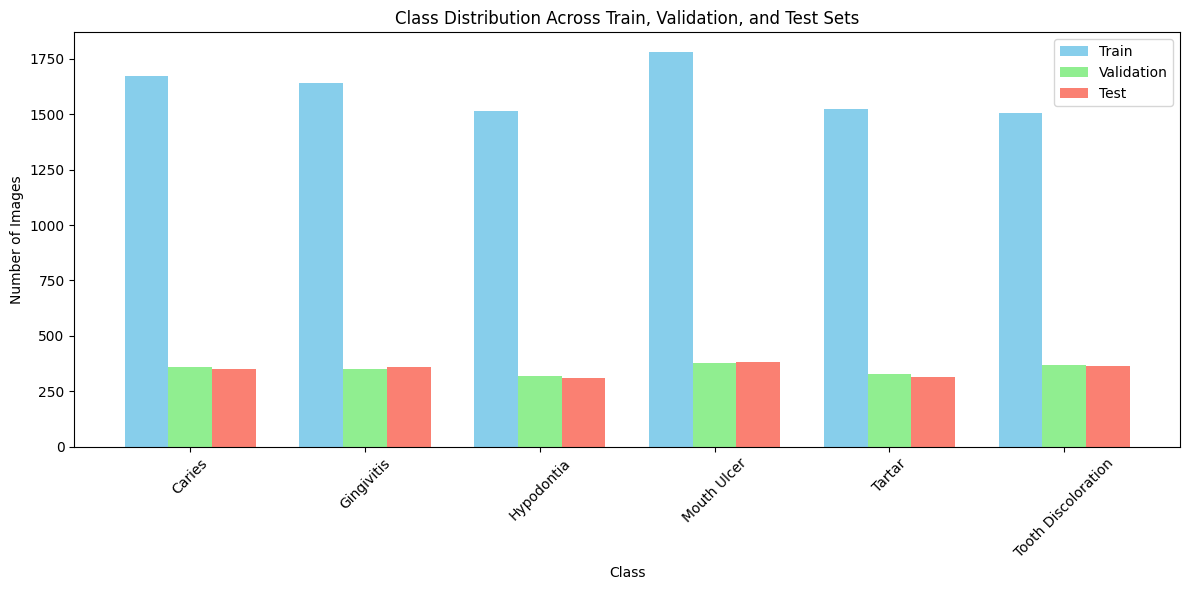

In [30]:
from collections import Counter
train_class_counts = Counter(y_train)
valid_class_counts = Counter(y_valid)
test_class_counts = Counter(y_test)

labels = sorted(set(y_train) | set(y_valid) | set(y_test))
train_counts = [train_class_counts.get(label, 0) for label in labels]
valid_counts = [valid_class_counts.get(label, 0) for label in labels]
test_counts = [test_class_counts.get(label, 0) for label in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, train_counts, width, label='Train', color='skyblue')
plt.bar(x, valid_counts, width, label='Validation', color='lightgreen')
plt.bar(x + width, test_counts, width, label='Test', color='salmon')

plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution Across Train, Validation, and Test Sets')
plt.xticks(x, labels, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Combining Training and Validation Datasets for Cross Validation

In [12]:
X_combined = np.concatenate((X_train, X_valid), axis=0)
y_combined = np.concatenate((y_train, y_valid), axis=0)

# Shuffle training data

In [13]:
X_combined, y_combined = shuffle(X_combined, y_combined, random_state=42)

# Encoding Labels Using LabelEncoder

In [14]:
le = LabelEncoder()
y_combined_encoded = le.fit_transform(y_combined)
y_test_encoded = le.transform(y_test)

# Feature Scaling Using StandardScaler

In [15]:
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)
X_test_scaled = scaler.transform(X_test)

# SVM Model

In [16]:
svm_model = SVC(kernel='rbf', C=35, gamma='scale', decision_function_shape='ovo')

# Support Vector Classification with 5-Fold Cross-Validation

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_model, X_combined_scaled, y_combined_encoded, cv=kf, scoring='accuracy')

# Accuracy Scores for each Fold as well as the Mean Accuracy across All Folds

In [38]:
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))

Cross-validation scores: [0.86164325 0.85866326 0.85483184 0.84716901 0.86201022]
Mean cross-validation accuracy: 85.69%


# Evaluating Accuracy on Test Data

In [37]:
svm_model.fit(X_combined_scaled, y_combined_encoded)
y_test_svm_pred = svm_model.predict(X_test_scaled)
print("SVM Test Accuracy: {:.2f}%".format(accuracy_score(y_test_encoded, y_test_svm_pred) * 100))

SVM Test Accuracy: 85.21%


# Saving Model Artifacts: Label Encoder, Scaler, and SVM Model

In [20]:
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(svm_model, 'svm_model.pkl')

['svm_model.pkl']

# Classification Report

In [21]:
print("SVM Classification Report:")
print(classification_report(y_test_encoded, y_test_svm_pred))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       352
           1       0.81      0.62      0.70       359
           2       0.97      0.98      0.98       311
           3       0.92      0.92      0.92       381
           4       0.67      0.85      0.75       316
           5       0.86      0.90      0.88       363

    accuracy                           0.85      2082
   macro avg       0.85      0.85      0.85      2082
weighted avg       0.85      0.85      0.85      2082



# Confusion Matrix

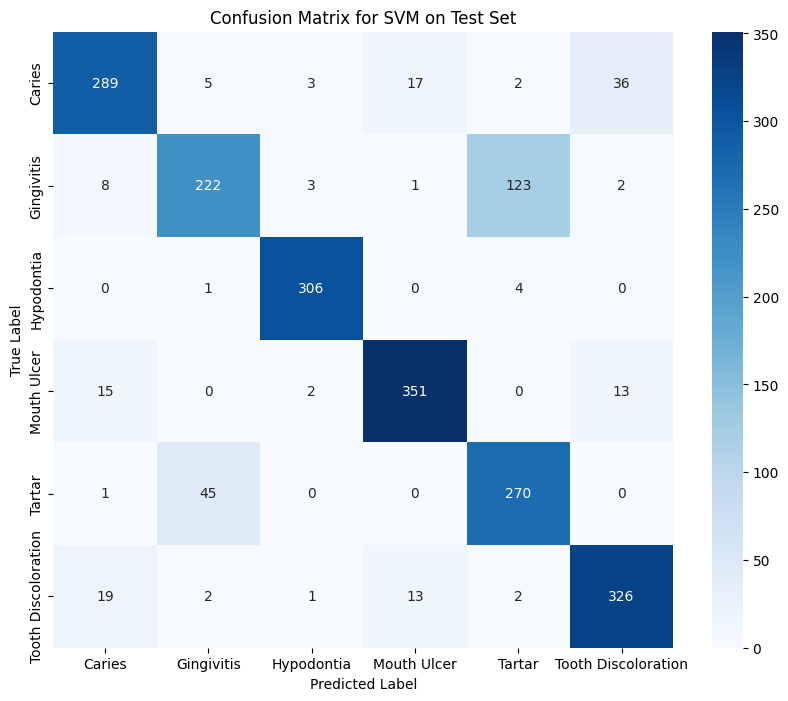

In [22]:
conf_matrix = confusion_matrix(y_test_encoded, y_test_svm_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix for SVM on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#  Load Trained Model and Predict Gender Class from a New Image

The predicted class for the image is: Gingivitis


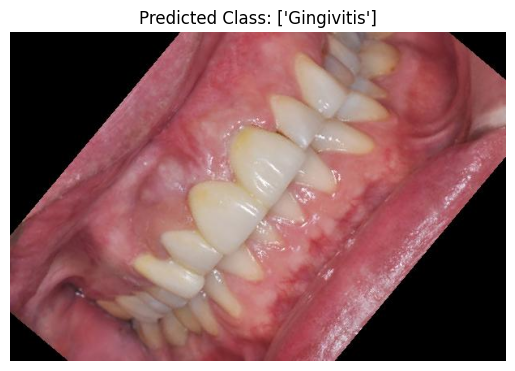

In [23]:
le = joblib.load('label_encoder.pkl')
scaler = joblib.load('scaler.pkl')
svm_model = joblib.load('svm_model.pkl')

image_path = "/content/Diseases/test/Gingivitis/(1974).jpg"
img_size = (150, 200)

def preprocess_image(image_path, img_size=(150, 200)):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Unable to read image from path: {image_path}")
    img_resized = cv2.resize(img, img_size)
    img_rescaled = np.expand_dims(img_resized, axis=0) / 255.0
    return img_rescaled

def extract_features_for_prediction(image_path, img_size=(150, 200)):
    img_rescaled = preprocess_image(image_path, img_size)
    feature = feature_extractor_model.predict(img_rescaled, verbose=0)
    return feature.flatten()


image_features = extract_features_for_prediction(image_path, img_size)
image_features_scaled = scaler.transform([image_features])
predicted_class_encoded = svm_model.predict(image_features_scaled)
predicted_class_label = le.inverse_transform(predicted_class_encoded)

print(f"The predicted class for the image is: {predicted_class_label[0]}")
img = cv2.imread(image_path, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title(f"Predicted Class: {predicted_class_label}")
plt.axis('off')
plt.show()